In [1]:
import pandas as pd
import numpy as np
import re
import nltk

In [2]:
df = pd.read_csv("Tweets.csv")
df = df[['text','airline_sentiment']]
df.columns = ['tweet','sentiment']
df.head()

,tweet,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_tweet'] = df['tweet'].apply(clean_text)

df.head()

,tweet,sentiment,clean_tweet
0,@VirginAmerica What @dhepburn said.,neutral,said
1,@VirginAmerica plus you've added commercials t...,positive,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,neutral,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,negative,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,negative,really big bad thing


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

X = df['clean_tweet']
y = df['sentiment'].map({'negative':0,'neutral':1,'positive':2})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

print("Data ready")

Data ready


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_shape=(50,)))
model.add(LSTM(64))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 50, 128)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 691,587 (2.64 MB)

 Trainable params: 691,587 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train_pad, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.6636 - loss: 0.7886 - val_accuracy: 0.7529 - val_loss: 0.6062
Epoch 2/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8101 - loss: 0.4817 - val_accuracy: 0.7875 - val_loss: 0.5555
Epoch 3/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8681 - loss: 0.3519 - val_accuracy: 0.7849 - val_loss: 0.5751


In [8]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7944 - loss: 0.5577
Test Accuracy: 0.7943989038467407


In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step  
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1889
           1       0.60      0.58      0.59       580
           2       0.74      0.70      0.72       459

    accuracy                           0.79      2928
   macro avg       0.73      0.72      0.73      2928
weighted avg       0.79      0.79      0.79      2928



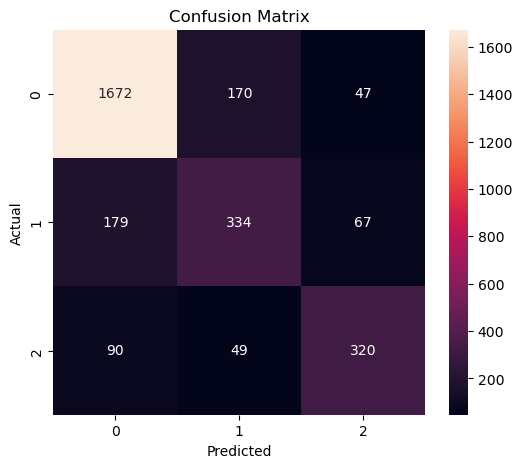

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()